<a href="https://colab.research.google.com/github/mebre7/house-price-predictor-mlops/blob/colab_branch/notebooks/02_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering
Feature engineering is the process of using domain knowledge to create new features from existing data. It involves transforming raw data into a format that is more suitable for machine learning algorithms, which can lead to improved model performance.
- In this notebook of the house price predictor project, I will be performing feature engineering on the dataset to create new features that can help improve the predictive power of the model. This may include creating interaction terms, polynomial features, or aggregating existing features to capture more complex relationships in the data.

## Data loading

In [127]:
from sqlalchemy import create_engine, text
import pandas as pd
from urllib.parse import quote_plus
from google.colab import userdata

In [128]:
DB_USER = userdata.get("SUPABASE_USER")
DB_PASSWORD = quote_plus(userdata.get("SUPABASE_PASSWORD"))
DB_HOST = userdata.get("SUPABASE_HOST")
DB_PORT = userdata.get("SUPABASE_PORT")
DB_NAME = userdata.get("SUPABASE_NAME")

# 2. Build SQLAlchemy connection string
DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)
with engine.connect() as conn:
    df = pd.read_sql(
        text("SELECT * FROM housing_data"),
        conn
    )

In [129]:
df.head()

,Order,PID,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,...,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,None,IR1,Lvl,...,0,None,None,None,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,None,Reg,Lvl,...,0,None,MnPrv,None,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,None,IR1,Lvl,...,0,None,None,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,None,Reg,Lvl,...,0,None,None,None,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,None,IR1,Lvl,...,0,None,MnPrv,None,0,3,2010,WD,Normal,189900


In [130]:
df = df.drop(columns=["Order", "PID"])

In [131]:
df.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice
0,20,RL,141.0,31770,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,None,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,MnPrv,None,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,None,Reg,Lvl,AllPub,Corner,...,0,None,None,None,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,...,0,None,MnPrv,None,0,3,2010,WD,Normal,189900


## Import Packages

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

## Features classification

**1. Numerical features**

In [133]:
# define numerical features
numerical_features_all = df.select_dtypes(include=[np.number]).columns.tolist()

In [134]:
# Discrete features
discrete_num_features = ['MS_SubClass', 'Overall_Qual', 'Overall_Cond', 'Bsmt_Full_Bath', 'Bsmt_Half_Bath', 'Full_Bath', 'Half_Bath', 'Bedroom_AbvGr', 'Kitchen_AbvGr', 'TotRms_AbvGrd', 'Fireplaces', 'Garage_Cars']
discrete_num_features

['MS_SubClass',
 'Overall_Qual',
 'Overall_Cond',
 'Bsmt_Full_Bath',
 'Bsmt_Half_Bath',
 'Full_Bath',
 'Half_Bath',
 'Bedroom_AbvGr',
 'Kitchen_AbvGr',
 'TotRms_AbvGrd',
 'Fireplaces',
 'Garage_Cars']

In [135]:
# Continuous features
continuous_num_features = list(set(numerical_features_all) - set(discrete_num_features))
continuous_num_features

['Year_Remod/Add',
 '2nd_Flr_SF',
 '3Ssn_Porch',
 '1st_Flr_SF',
 'Year_Built',
 'Lot_Area',
 'Garage_Area',
 'Screen_Porch',
 'Enclosed_Porch',
 'Wood_Deck_SF',
 'Open_Porch_SF',
 'Total_Bsmt_SF',
 'SalePrice',
 'Garage_Yr_Blt',
 'Low_Qual_Fin_SF',
 'Mas_Vnr_Area',
 'Yr_Sold',
 'Gr_Liv_Area',
 'Pool_Area',
 'Lot_Frontage',
 'Bsmt_Unf_SF',
 'Mo_Sold',
 'BsmtFin_SF_1',
 'BsmtFin_SF_2',
 'Misc_Val']

In [136]:
num_feats_int = list(set(numerical_features_all) - set(discrete_num_features)) + ['SalePrice']

**2. Categorical features**

In [137]:
# define categorical features
categorical_features = df.select_dtypes(include=[object]).columns.tolist()

In [138]:
# Add discrete features to categorical features list
categorical_features_all = list(set(categorical_features + discrete_num_features))

In [139]:
categorical_features_all

['Alley',
 'Kitchen_AbvGr',
 'Sale_Type',
 'Bldg_Type',
 'Exter_Qual',
 'Lot_Shape',
 'Kitchen_Qual',
 'Mas_Vnr_Type',
 'MS_SubClass',
 'Central_Air',
 'Bsmt_Half_Bath',
 'Lot_Config',
 'Garage_Qual',
 'Roof_Style',
 'Condition_1',
 'Utilities',
 'Bsmt_Full_Bath',
 'BsmtFin_Type_1',
 'Full_Bath',
 'Half_Bath',
 'Fireplaces',
 'Garage_Type',
 'TotRms_AbvGrd',
 'Condition_2',
 'Electrical',
 'Street',
 'Exterior_2nd',
 'Bsmt_Exposure',
 'Land_Slope',
 'Exterior_1st',
 'Foundation',
 'Heating',
 'Garage_Finish',
 'Sale_Condition',
 'Pool_QC',
 'Land_Contour',
 'Misc_Feature',
 'Fireplace_Qu',
 'Paved_Drive',
 'Garage_Cars',
 'Neighborhood',
 'Bedroom_AbvGr',
 'Heating_QC',
 'Bsmt_Qual',
 'Roof_Matl',
 'Overall_Cond',
 'Bsmt_Cond',
 'Garage_Cond',
 'Overall_Qual',
 'BsmtFin_Type_2',
 'Functional',
 'Fence',
 'House_Style',
 'Exter_Cond',
 'MS_Zoning']

**Change data types of `categorical_features` to `category` for memory efficiency and better performance in modeling.**

In [140]:
for col in categorical_features_all:
    df[col] = df[col].astype('category')

In [141]:
df[categorical_features_all].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 55 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Alley           198 non-null    category
 1   Kitchen_AbvGr   2930 non-null   category
 2   Sale_Type       2930 non-null   category
 3   Bldg_Type       2930 non-null   category
 4   Exter_Qual      2930 non-null   category
 5   Lot_Shape       2930 non-null   category
 6   Kitchen_Qual    2930 non-null   category
 7   Mas_Vnr_Type    1155 non-null   category
 8   MS_SubClass     2930 non-null   category
 9   Central_Air     2930 non-null   category
 10  Bsmt_Half_Bath  2928 non-null   category
 11  Lot_Config      2930 non-null   category
 12  Garage_Qual     2771 non-null   category
 13  Roof_Style      2930 non-null   category
 14  Condition_1     2930 non-null   category
 15  Utilities       2930 non-null   category
 16  Bsmt_Full_Bath  2928 non-null   category
 17  BsmtFin_Type_1

**3. Temporal features**

In [142]:
date_year = ['Year_Built', 'Year_Remod/Add', 'Garage_Yr_Blt', 'Yr_Sold', ]
date_month = ['Mo_Sold']

for col in date_year:
    df[col] = pd.to_datetime(df[col], format='%Y').dt.year

for col in date_month:
    df[col] = pd.to_datetime(df[col], format='%m').dt.month

In [143]:
# Temporal features
temporal_features = date_year + date_month
temporal_features

['Year_Built', 'Year_Remod/Add', 'Garage_Yr_Blt', 'Yr_Sold', 'Mo_Sold']

**Summarize**

In [144]:

# print columns
print(f'{len(numerical_features_all)} numerical features: {numerical_features_all}')
print(f'\n{len(categorical_features)} categorical features: {categorical_features}')
print(f'\n{len(temporal_features)} temporal features: {temporal_features}')

37 numerical features: ['MS_SubClass', 'Lot_Frontage', 'Lot_Area', 'Overall_Qual', 'Overall_Cond', 'Year_Built', 'Year_Remod/Add', 'Mas_Vnr_Area', 'BsmtFin_SF_1', 'BsmtFin_SF_2', 'Bsmt_Unf_SF', 'Total_Bsmt_SF', '1st_Flr_SF', '2nd_Flr_SF', 'Low_Qual_Fin_SF', 'Gr_Liv_Area', 'Bsmt_Full_Bath', 'Bsmt_Half_Bath', 'Full_Bath', 'Half_Bath', 'Bedroom_AbvGr', 'Kitchen_AbvGr', 'TotRms_AbvGrd', 'Fireplaces', 'Garage_Yr_Blt', 'Garage_Cars', 'Garage_Area', 'Wood_Deck_SF', 'Open_Porch_SF', 'Enclosed_Porch', '3Ssn_Porch', 'Screen_Porch', 'Pool_Area', 'Misc_Val', 'Mo_Sold', 'Yr_Sold', 'SalePrice']

43 categorical features: ['MS_Zoning', 'Street', 'Alley', 'Lot_Shape', 'Land_Contour', 'Utilities', 'Lot_Config', 'Land_Slope', 'Neighborhood', 'Condition_1', 'Condition_2', 'Bldg_Type', 'House_Style', 'Roof_Style', 'Roof_Matl', 'Exterior_1st', 'Exterior_2nd', 'Mas_Vnr_Type', 'Exter_Qual', 'Exter_Cond', 'Foundation', 'Bsmt_Qual', 'Bsmt_Cond', 'Bsmt_Exposure', 'BsmtFin_Type_1', 'BsmtFin_Type_2', 'Heating', 'H

In [145]:
# total
print(f'Total features: {len(numerical_features_all) + len(categorical_features)}')

Total features: 80


## 1. Outlier Removal/Resolving

Important concepts in outlier detection! Here's a breakdown:

*   **Interquartile Range (IQR):** The IQR is a measure of statistical dispersion, representing the range of the middle 50% of your data. It's calculated as the difference between the third quartile (Q3) and the first quartile (Q1).

    *   **Q1 (First Quartile):** The value below which 25% of the data falls.
    *   **Q3 (Third Quartile):** The value below which 75% of the data falls.
    *   `IQR = Q3 - Q1`

*   **Outlier Thresholds (Lower Bound and Upper Bound):** These are calculated boundaries used to identify potential outliers in a dataset. They are derived using the IQR.

    *   **Lower Bound:** `Q1 - 1.5 * IQR`
    *   **Upper Bound:** `Q3 + 1.5 * IQR`

*   **Outlier vs. IQR:**
    *   The **IQR** itself is a measure of the spread of the central portion of the data, robust to extreme values.
    *   **Outliers** are data points that fall outside the calculated lower and upper bounds. The 1.5 multiplier in the threshold calculation is a commonly used convention (often referred to as the "1.5 IQR rule") to define what constitutes an outlier relative to the bulk of the data's spread. Any data point less than the lower bound or greater than the upper bound is considered an outlier.

In [146]:
num_feats_int

['Year_Remod/Add',
 '2nd_Flr_SF',
 '3Ssn_Porch',
 '1st_Flr_SF',
 'Year_Built',
 'Lot_Area',
 'Garage_Area',
 'Screen_Porch',
 'Enclosed_Porch',
 'Wood_Deck_SF',
 'Open_Porch_SF',
 'Total_Bsmt_SF',
 'SalePrice',
 'Garage_Yr_Blt',
 'Low_Qual_Fin_SF',
 'Mas_Vnr_Area',
 'Yr_Sold',
 'Gr_Liv_Area',
 'Pool_Area',
 'Lot_Frontage',
 'Bsmt_Unf_SF',
 'Mo_Sold',
 'BsmtFin_SF_1',
 'BsmtFin_SF_2',
 'Misc_Val',
 'SalePrice']

In [147]:
# Calculate outlier thresholds
def outlier_thresholds(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    #outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return lower_bound, upper_bound

In [148]:
# detect outliers
def detect_outliers(df, column):
    if pd.api.types.is_numeric_dtype(df[column]):
        low, up = outlier_thresholds(df, column)
        return (df[column] > up) | (df[column] < low)
    else:
        return pd.Series(False, index=df.index)

In [149]:
outliers_df = pd.DataFrame(index=df.index)
for col in numerical_features_all:
    outliers_df[col] = detect_outliers(df, col)

# Display the count of outliers per column
print("Number of outliers per numerical column:")
print(outliers_df.sum())

Number of outliers per numerical column:
MS_SubClass          0
Lot_Frontage       187
Lot_Area           127
Overall_Qual         0
Overall_Cond         0
Year_Built           9
Year_Remod/Add       0
Mas_Vnr_Area       200
BsmtFin_SF_1        15
BsmtFin_SF_2       351
Bsmt_Unf_SF         56
Total_Bsmt_SF      123
1st_Flr_SF          43
2nd_Flr_SF           8
Low_Qual_Fin_SF     40
Gr_Liv_Area         75
Bsmt_Full_Bath       0
Bsmt_Half_Bath       0
Full_Bath            0
Half_Bath            0
Bedroom_AbvGr        0
Kitchen_AbvGr        0
TotRms_AbvGrd        0
Fireplaces           0
Garage_Yr_Blt        3
Garage_Cars          0
Garage_Area         42
Wood_Deck_SF        67
Open_Porch_SF      159
Enclosed_Porch     459
3Ssn_Porch          37
Screen_Porch       256
Pool_Area           13
Misc_Val           103
Mo_Sold              0
Yr_Sold              0
SalePrice          137
dtype: int64


In [150]:
len(numerical_features_all)

37

In [151]:
len(discrete_num_features)

12

In [152]:
len(num_feats_int)

26

> $26 = 37 - 12 + 1$

In [153]:
display(outliers_df.head())

,MS_SubClass,Lot_Frontage,Lot_Area,Overall_Qual,Overall_Cond,Year_Built,Year_Remod/Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,...,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,3Ssn_Porch,Screen_Porch,Pool_Area,Misc_Val,Mo_Sold,Yr_Sold,SalePrice
0,False,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [154]:
# Function to check all numeric columns for outliers
def inspect_outliers(df, col_list):
    results = {}
    for col in col_list:
        results[col] = detect_outliers(df, col).any() if pd.api.types.is_numeric_dtype(df[col]) else False
    return results

In [155]:
# Function to display columns with outlier information
def display_outlier_info(df, col_list):
    print("Outlier thresholds for the numeric column")
    for col in col_list:
        low, up = outlier_thresholds(df, col)
        print(f"{col} : Lower Bound: {low}, Upper Bound: {up}", end="\n")
    print(end="\n\n")
    outliers_absent = []
    outliers_present = []
    for col, value in inspect_outliers(df, col_list).items():
        if value:
            outliers_present.append(col)
        else:
            outliers_absent.append(col)
    print("Columns with outliers")
    print(outliers_present)
    print(f"column count: {len(outliers_present)}", end="\n\n")
    print("Columns with no outliers")
    print(outliers_absent)
    print(f"column count: {len(outliers_absent)}", end="\n\n")

    return outliers_present, outliers_absent

In [156]:
# Resolve Outliers
def threshold_resolution(df, column):
    low, up = outlier_thresholds(df, column)
    df.loc[df[column] < low, column] = low
    df.loc[df[column] > up, column] = up
    return low, up

In [157]:
current_numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
outliers_present, outliers_absent = display_outlier_info(df, current_numerical_columns)

Outlier thresholds for the numeric column
Lot_Frontage : Lower Bound: 25.0, Upper Bound: 113.0
Lot_Area : Lower Bound: 1267.75, Upper Bound: 17727.75
Year_Built : Lower Bound: 1883.5, Upper Bound: 2071.5
Year_Remod/Add : Lower Bound: 1906.5, Upper Bound: 2062.5
Mas_Vnr_Area : Lower Bound: -246.0, Upper Bound: 410.0
BsmtFin_SF_1 : Lower Bound: -1101.0, Upper Bound: 1835.0
BsmtFin_SF_2 : Lower Bound: 0.0, Upper Bound: 0.0
Bsmt_Unf_SF : Lower Bound: -655.5, Upper Bound: 1676.5
Total_Bsmt_SF : Lower Bound: 29.5, Upper Bound: 2065.5
1st_Flr_SF : Lower Bound: 114.625, Upper Bound: 2145.625
2nd_Flr_SF : Lower Bound: -1055.625, Upper Bound: 1759.375
Low_Qual_Fin_SF : Lower Bound: 0.0, Upper Bound: 0.0
Gr_Liv_Area : Lower Bound: 200.875, Upper Bound: 2667.875
Garage_Yr_Blt : Lower Bound: 1897.0, Upper Bound: 2065.0
Garage_Area : Lower Bound: -64.0, Upper Bound: 960.0
Wood_Deck_SF : Lower Bound: -252.0, Upper Bound: 420.0
Open_Porch_SF : Lower Bound: -105.0, Upper Bound: 175.0
Enclosed_Porch : L

**Now remove outliers**

In [158]:
for col in outliers_present:
    if col not in ['SalePrice']:
        threshold_resolution(df, col)

In [159]:
outliers_present, outliers_absent = display_outlier_info(df, current_numerical_columns)

Outlier thresholds for the numeric column
Lot_Frontage : Lower Bound: 25.0, Upper Bound: 113.0
Lot_Area : Lower Bound: 1267.75, Upper Bound: 17727.75
Year_Built : Lower Bound: 1883.5, Upper Bound: 2071.5
Year_Remod/Add : Lower Bound: 1906.5, Upper Bound: 2062.5
Mas_Vnr_Area : Lower Bound: -246.0, Upper Bound: 410.0
BsmtFin_SF_1 : Lower Bound: -1101.0, Upper Bound: 1835.0
BsmtFin_SF_2 : Lower Bound: 0.0, Upper Bound: 0.0
Bsmt_Unf_SF : Lower Bound: -655.5, Upper Bound: 1676.5
Total_Bsmt_SF : Lower Bound: 29.5, Upper Bound: 2065.5
1st_Flr_SF : Lower Bound: 114.625, Upper Bound: 2145.625
2nd_Flr_SF : Lower Bound: -1055.625, Upper Bound: 1759.375
Low_Qual_Fin_SF : Lower Bound: 0.0, Upper Bound: 0.0
Gr_Liv_Area : Lower Bound: 200.875, Upper Bound: 2667.875
Garage_Yr_Blt : Lower Bound: 1897.0, Upper Bound: 2065.0
Garage_Area : Lower Bound: -64.0, Upper Bound: 960.0
Wood_Deck_SF : Lower Bound: -252.0, Upper Bound: 420.0
Open_Porch_SF : Lower Bound: -105.0, Upper Bound: 175.0
Enclosed_Porch : L

> **Now no columns with outliers except `SalePrice`**

## 2. Train-Test split

In [160]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [161]:
X_train.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition
381,20,RL,80.0,10400.00,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,6,2009,WD,Family
834,60,RL,NaN,17727.75,Pave,NaN,IR2,Low,AllPub,CulDSac,...,0,0,NaN,NaN,NaN,0,6,2009,WD,Abnorml
1898,20,RL,75.0,7388.00,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,7,2007,WD,Normal
678,90,RL,60.0,8544.00,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,6,2009,WD,Normal
700,70,RM,57.0,6406.00,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,10,2009,WD,Normal


In [162]:
X_test.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition
1357,50,RL,60.0,9144.0,Pave,Pave,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,3,2008,WD,Normal
2367,160,RM,25.0,1953.0,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
2822,20,RL,73.0,16133.0,Pave,NaN,Reg,HLS,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,12,2006,WD,Abnorml
2126,20,RL,70.0,16561.0,Pave,NaN,IR2,Low,AllPub,Inside,...,0,0,NaN,GdPrv,NaN,0,7,2007,WD,Normal
1544,160,RM,25.0,1950.0,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,GdPrv,NaN,0,7,2008,COD,Normal


In [163]:
y_train.head()

,SalePrice
381,152000
834,185000
1898,150750
678,92900
700,150000


In [164]:
y_test.head()

,SalePrice
1357,162500
2367,83000
2822,119900
2126,147900
1544,151000


## 3. Missing Value Handling (Imputation)

In [165]:
count = df.isnull().sum().sort_values(ascending=False)
percentage = ((df.isnull().sum() / df.isnull().count()) * 100).sort_values(ascending=False)
null_values = pd.concat([count, percentage], axis=1, keys=['Count', 'Percentage'])

In [166]:
null_values.head()

,Count,Percentage
Pool_QC,2917,99.556314
Misc_Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas_Vnr_Type,1775,60.580205


In [167]:
df.columns.to_list()

['MS_SubClass',
 'MS_Zoning',
 'Lot_Frontage',
 'Lot_Area',
 'Street',
 'Alley',
 'Lot_Shape',
 'Land_Contour',
 'Utilities',
 'Lot_Config',
 'Land_Slope',
 'Neighborhood',
 'Condition_1',
 'Condition_2',
 'Bldg_Type',
 'House_Style',
 'Overall_Qual',
 'Overall_Cond',
 'Year_Built',
 'Year_Remod/Add',
 'Roof_Style',
 'Roof_Matl',
 'Exterior_1st',
 'Exterior_2nd',
 'Mas_Vnr_Type',
 'Mas_Vnr_Area',
 'Exter_Qual',
 'Exter_Cond',
 'Foundation',
 'Bsmt_Qual',
 'Bsmt_Cond',
 'Bsmt_Exposure',
 'BsmtFin_Type_1',
 'BsmtFin_SF_1',
 'BsmtFin_Type_2',
 'BsmtFin_SF_2',
 'Bsmt_Unf_SF',
 'Total_Bsmt_SF',
 'Heating',
 'Heating_QC',
 'Central_Air',
 'Electrical',
 '1st_Flr_SF',
 '2nd_Flr_SF',
 'Low_Qual_Fin_SF',
 'Gr_Liv_Area',
 'Bsmt_Full_Bath',
 'Bsmt_Half_Bath',
 'Full_Bath',
 'Half_Bath',
 'Bedroom_AbvGr',
 'Kitchen_AbvGr',
 'Kitchen_Qual',
 'TotRms_AbvGrd',
 'Functional',
 'Fireplaces',
 'Fireplace_Qu',
 'Garage_Type',
 'Garage_Yr_Blt',
 'Garage_Finish',
 'Garage_Cars',
 'Garage_Area',
 'Garage_Qu

**Visualize missing values**

In [168]:
fig = px.bar(x=null_values.index, y=null_values['Percentage'],
             labels={'x': 'Features', 'y': 'Percent of missing values'},
             title='Percent missing data by feature')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

**1. Structural Absence (Replace `NaN` with `None` or `0`)**

These columns use missing values to denote that the feature does not exist on the property.

- **`structural_categorical` (Fill with `None`)**

In [169]:
structural_categorical = [
    'Alley', 'Mas_Vnr_Type', 'Bsmt_Qual', 'Bsmt_Cond', 'Bsmt_Exposure',
    'BsmtFin_Type_1', 'BsmtFin_Type_2', 'Fireplace_Qu', 'Garage_Type',
    'Garage_Finish', 'Garage_Qual', 'Garage_Cond', 'Pool_QC', 'Fence', 'Misc_Feature'
]

```
df.Alley=["No Alley" if x is np.nan else x for x in df.Alley]
df.Mas_Vnr_Type=["Missing" if x is np.nan else x for x in df.Mas_Vnr_Type]
df.Bsmt_Qual=["No Bsmnt" if x is np.nan else x for x in df.Bsmt_Qual]
df.Bsmt_Cond=["No Bsmnt" if x is np.nan else x for x in df.Bsmt_Cond]
df.Bsmt_Exposure=["No Bsmnt" if x is np.nan else x for x in df.Bsmt_Exposure]
df.BsmtFin_Type_1=["No Bsmnt" if x is np.nan else x for x in df.BsmtFin_Type_1]
df.BsmtFin_Type_2=["No Bsmnt" if x is np.nan else x for x in df.BsmtFin_Type_2]
df.Fireplace_Qu=["No Firepl" if x is np.nan else x for x in df.Fireplace_Qu]
df.Garage_Type=["No Grg" if x is np.nan else x for x in df.Garage_Type]
df.Garage_Finish=["No Grg" if x is np.nan else x for x in df.Garage_Finish]
df.Garage_Qual=["No Grg" if x is np.nan else x for x in df.Garage_Qual]
df.Garage_Cond=["No Grg" if x is np.nan else x for x in df.Garage_Cond]
df.Pool_QC=["No Pool" if x is np.nan else x for x in df.Pool_QC]
df.Fence=["No Fence" if x is np.nan else x for x in df.Fence]
df.Misc_Feature=["None" if x is np.nan else x for x in df.Misc_Feature]
```

```py
df['Alley'] = df['Alley'].fillna('No Alley')
df['Mas_Vnr_Type'] = df['Mas_Vnr_Type'].fillna('Missing')
df['Bsmt_Qual'] = df['Bsmt_Qual'].fillna('No Bsmnt')
df['Bsmt_Cond'] = df['Bsmt_Cond'].fillna('No Bsmnt')
df['Bsmt_Exposure'] = df['Bsmt_Exposure'].fillna('No Bsmnt')
df['BsmtFin_Type_1'] = df['BsmtFin_Type_1'].fillna('No Bsmnt')
df['BsmtFin_Type_2'] = df['BsmtFin_Type_2'].fillna('No Bsmnt')
df['Fireplace_Qu'] = df['Fireplace_Qu'].fillna('No Firepl')
df['Garage_Type'] = df['Garage_Type'].fillna('No Grg')
df['Garage_Finish'] = df['Garage_Finish'].fillna('No Grg')
df['Garage_Qual'] = df['Garage_Qual'].fillna('No Grg')
df['Garage_Cond'] = df['Garage_Cond'].fillna('No Grg')
df['Pool_QC'] = df['Pool_QC'].fillna('No Pool')
df['Fence'] = df['Fence'].fillna('No Fence')
df['Misc_Feature'] = df['Misc_Feature'].fillna('None')
```

In [170]:
fill_values = {
    'Alley': 'No Alley',
    'Mas_Vnr_Type': 'Missing',
    'Bsmt_Qual': 'No Bsmnt',
    'Bsmt_Cond': 'No Bsmnt',
    'Bsmt_Exposure': 'No Bsmnt',
    'BsmtFin_Type_1': 'No Bsmnt',
    'BsmtFin_Type_2': 'No Bsmnt',
    'Fireplace_Qu': 'No Firepl',
    'Garage_Type': 'No Grg',
    'Garage_Finish': 'No Grg',
    'Garage_Qual': 'No Grg',
    'Garage_Cond': 'No Grg',
    'Pool_QC': 'No Pool',
    'Fence': 'No Fence',
    'Misc_Feature': 'None'
}

for col, fill_value in fill_values.items():
    if fill_value not in df[col].cat.categories:
        df[col] = df[col].cat.add_categories(fill_value)
    df[col] = df[col].fillna(fill_value)

In [171]:
df[structural_categorical].isnull().sum()

,0
Alley,0
Mas_Vnr_Type,0
Bsmt_Qual,0
Bsmt_Cond,0
Bsmt_Exposure,0
BsmtFin_Type_1,0
BsmtFin_Type_2,0
Fireplace_Qu,0
Garage_Type,0
Garage_Finish,0


- **`structural_numerical` (Fill with `0`)**

In [172]:
structural_numerical = [
    'BsmtFin_SF_1', 'BsmtFin_SF_2', 'Bsmt_Unf_SF', 'Total_Bsmt_SF',
    'Bsmt_Full_Bath', 'Bsmt_Half_Bath', 'Garage_Cars', 'Garage_Area', 'Mas_Vnr_Area'
]

In [173]:
for col in structural_numerical:
    df[col] = df[col].fillna(0)

In [174]:
df[structural_numerical].isnull().sum()

,0
BsmtFin_SF_1,0
BsmtFin_SF_2,0
Bsmt_Unf_SF,0
Total_Bsmt_SF,0
Bsmt_Full_Bath,0
Bsmt_Half_Bath,0
Garage_Cars,0
Garage_Area,0
Mas_Vnr_Area,0


**Checking**

In [175]:
df[structural_numerical + structural_categorical].isnull().sum().sum()

np.int64(0)

In [176]:
len(structural_numerical + structural_categorical)

24

In [177]:
features_with_missing_values = list(set(df.columns.to_list()) - set(structural_numerical + structural_categorical))
print(len(features_with_missing_values))
features_with_missing_values

56


['Kitchen_AbvGr',
 'Sale_Type',
 'Bldg_Type',
 'Exter_Qual',
 'Lot_Shape',
 'Year_Remod/Add',
 '2nd_Flr_SF',
 'Kitchen_Qual',
 'MS_SubClass',
 'Central_Air',
 'Lot_Config',
 '3Ssn_Porch',
 'Condition_1',
 '1st_Flr_SF',
 'Utilities',
 'Exter_Cond',
 'Roof_Style',
 'Year_Built',
 'Lot_Area',
 'Screen_Porch',
 'Full_Bath',
 'Half_Bath',
 'Fireplaces',
 'Enclosed_Porch',
 'Wood_Deck_SF',
 'TotRms_AbvGrd',
 'Condition_2',
 'Open_Porch_SF',
 'Electrical',
 'Street',
 'Exterior_2nd',
 'Land_Slope',
 'Exterior_1st',
 'Foundation',
 'Heating',
 'Sale_Condition',
 'Land_Contour',
 'SalePrice',
 'Garage_Yr_Blt',
 'Paved_Drive',
 'Low_Qual_Fin_SF',
 'Neighborhood',
 'Bedroom_AbvGr',
 'Yr_Sold',
 'Gr_Liv_Area',
 'Heating_QC',
 'Roof_Matl',
 'Pool_Area',
 'Lot_Frontage',
 'Overall_Qual',
 'Mo_Sold',
 'Functional',
 'House_Style',
 'Overall_Cond',
 'Misc_Val',
 'MS_Zoning']

> Out of $80$ total features, $23$ features with missing values are handled considering _structuring absence_. Remaining $57$ will be handled by _statistical imputation_.

In [178]:
df.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice
0,20,RL,113.0,17727.75,Pave,No Alley,IR1,Lvl,AllPub,Corner,...,0,No Pool,No Fence,None,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622.00,Pave,No Alley,Reg,Lvl,AllPub,Inside,...,0,No Pool,MnPrv,None,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267.00,Pave,No Alley,IR1,Lvl,AllPub,Corner,...,0,No Pool,No Fence,Gar2,0,6,2010,WD,Normal,172000
3,20,RL,93.0,11160.00,Pave,No Alley,Reg,Lvl,AllPub,Corner,...,0,No Pool,No Fence,None,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830.00,Pave,No Alley,IR1,Lvl,AllPub,Inside,...,0,No Pool,MnPrv,None,0,3,2010,WD,Normal,189900


**2. Statistical Imputation (True Missingness/Clerical Errors)**

These features are physically required for a house to exist. Missing data here represents a processing omission or clerical typo.

- **`spatial_numerical` (Impute using the median of their specific `Neighborhood`)**

In [179]:
spatial_numerical = ['Lot_Frontage']

In [180]:
df[spatial_numerical].isnull().sum()

,0
Lot_Frontage,490


In [181]:
df['Lot_Frontage'].interpolate(method='linear', axis=0, inplace=True)

In [182]:
df[spatial_numerical].isnull().sum()

,0
Lot_Frontage,0


- **`mode_categorical` (Impute using the column's global mode/most frequent item)**

In [183]:
mode_categorical = [
    'Utilities', 'Exterior_1st', 'Exterior_2nd', 'Electrical',
    'Kitchen_Qual', 'Functional', 'Sale_Type'
]

In [184]:
df[mode_categorical].isnull().sum()

,0
Utilities,0
Exterior_1st,0
Exterior_2nd,0
Electrical,1
Kitchen_Qual,0
Functional,0
Sale_Type,0


In [185]:
df[mode_categorical].head()

,Utilities,Exterior_1st,Exterior_2nd,Electrical,Kitchen_Qual,Functional,Sale_Type
0,AllPub,BrkFace,Plywood,SBrkr,TA,Typ,WD
1,AllPub,VinylSd,VinylSd,SBrkr,TA,Typ,WD
2,AllPub,Wd Sdng,Wd Sdng,SBrkr,Gd,Typ,WD
3,AllPub,BrkFace,BrkFace,SBrkr,Ex,Typ,WD
4,AllPub,VinylSd,VinylSd,SBrkr,TA,Typ,WD


In [186]:
for col in mode_categorical:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

- **`special_case_temporal` (Impute missing indices dynamically with that row's `Year_Built` value)**

In [187]:
special_case_temporal = ['Garage_Yr_Blt']

In [188]:
df[temporal_features].isnull().sum()

,0
Year_Built,0
Year_Remod/Add,0
Garage_Yr_Blt,159
Yr_Sold,0
Mo_Sold,0


In [189]:
df[temporal_features].head()

,Year_Built,Year_Remod/Add,Garage_Yr_Blt,Yr_Sold,Mo_Sold
0,1960.0,1960,1960.0,2010,5
1,1961.0,1961,1961.0,2010,6
2,1958.0,1958,1958.0,2010,6
3,1968.0,1968,1968.0,2010,4
4,1997.0,1998,1997.0,2010,3


In [190]:
df['Garage_Yr_Blt'] = df['Garage_Yr_Blt'].fillna(df['Year_Built'])

In [191]:
df[temporal_features].isnull().sum()

,0
Year_Built,0
Year_Remod/Add,0
Garage_Yr_Blt,0
Yr_Sold,0
Mo_Sold,0


**Final check for existence of null values**

In [192]:
# Null values left?
print(df.isnull().values.any())
if df.isnull().values.any():
  print("Yes, there exist null values!")
  null_counts = df.isnull().sum()
  null_counts = null_counts[null_counts > 0]
  print(null_counts)
else:
  print("No null values")

False
No null values


> **Final dataset with no missing values**

In [193]:
df.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice
0,20,RL,113.0,17727.75,Pave,No Alley,IR1,Lvl,AllPub,Corner,...,0,No Pool,No Fence,None,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622.00,Pave,No Alley,Reg,Lvl,AllPub,Inside,...,0,No Pool,MnPrv,None,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267.00,Pave,No Alley,IR1,Lvl,AllPub,Corner,...,0,No Pool,No Fence,Gar2,0,6,2010,WD,Normal,172000
3,20,RL,93.0,11160.00,Pave,No Alley,Reg,Lvl,AllPub,Corner,...,0,No Pool,No Fence,None,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830.00,Pave,No Alley,IR1,Lvl,AllPub,Inside,...,0,No Pool,MnPrv,None,0,3,2010,WD,Normal,189900


In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   MS_SubClass      2930 non-null   category
 1   MS_Zoning        2930 non-null   category
 2   Lot_Frontage     2930 non-null   float64 
 3   Lot_Area         2930 non-null   float64 
 4   Street           2930 non-null   category
 5   Alley            2930 non-null   category
 6   Lot_Shape        2930 non-null   category
 7   Land_Contour     2930 non-null   category
 8   Utilities        2930 non-null   category
 9   Lot_Config       2930 non-null   category
 10  Land_Slope       2930 non-null   category
 11  Neighborhood     2930 non-null   category
 12  Condition_1      2930 non-null   category
 13  Condition_2      2930 non-null   category
 14  Bldg_Type        2930 non-null   category
 15  House_Style      2930 non-null   category
 16  Overall_Qual     2930 non-null   category


## 4. Feature Creation / Engineering

In [195]:
import numpy as np
# New Features for Housing Dataset

# Total square footage
df['TotalSF'] = df['1st_Flr_SF'] + df['2nd_Flr_SF'] + df['Total_Bsmt_SF']

# Age of the house at time of sale
df['Age'] = df['Yr_Sold'] - df['Year_Built']

# Ensure Half_Bath and Bsmt_Half_Bath are numeric for calculations
df['Half_Bath'] = df['Half_Bath'].astype(int)
df['Bsmt_Half_Bath'] = df['Bsmt_Half_Bath'].astype(int)
df['Full_Bath'] = df['Full_Bath'].astype(int)
df['Bsmt_Full_Bath'] = df['Bsmt_Full_Bath'].astype(int)

# Total number of bathrooms
df['TotalBathrooms'] = (df['Full_Bath'] + (0.5 * df['Half_Bath']) +
                        df['Bsmt_Full_Bath'] + (0.5 * df['Bsmt_Half_Bath'])).astype('category')

# Boolean indicator for pool presence
df['HasPool'] = df['Pool_Area'].apply(lambda x: 1 if x > 0 else 0).astype('category')

# Total porch area
df['TotalPorchSF'] = df['Open_Porch_SF'] + df['Enclosed_Porch'] + df['3Ssn_Porch'] + df['Screen_Porch']

# Ensure Garage_Cars is numeric for calculations
df['Garage_Cars'] = df['Garage_Cars'].astype(int)

# Total parking capacity, considering paved drive
df['TotalParking'] = (df['Garage_Cars'] + df['Paved_Drive'].apply(lambda x:1 if x == 'Y' else 0)).astype('category')
# Boolean indicator for remodeling
df['Remodeled'] = (df['Year_Remod/Add'] != df['Year_Built']).astype(int).astype('category')
# Years since last remodel at time of sale
df['YearsSinceRemodel'] = df['Yr_Sold'] - df['Year_Remod/Add'].astype(int)

# Total number of rooms
df['TotalRooms'] = df['TotRms_AbvGrd'].astype('category') # TotRms_AbvGrd is already category

# Ratio of living area to lot area
df['LotRatio'] = df['Gr_Liv_Area'] / df['Lot_Area']

# Sale price per square foot (if SalePrice is available)
if 'SalePrice' in df.columns:
    df['PricePerSqFt'] = df['SalePrice'] / df['TotalSF']

# Categorical age group of the house
def age_group(age):
    if age <= 10:
        return 'New'
    elif age <= 30:
        return 'Modern'
    elif age <= 50:
        return 'Mature'
    else:
        return 'Old'

df['AgeGroup'] = df['Age'].apply(age_group).astype('category')

# Total outdoor living space
df['TotalOutdoorSF'] = df['Wood_Deck_SF'] + df['TotalPorchSF']

# Boolean indicator for fireplace presence
df['HasFireplace'] = df['Fireplaces'].apply(lambda x: 1 if x > 0 else 0).astype('category')

In [196]:
# Mapping for OverallQual to match ExterQual and KitchenQual ratings
overall_qual_map = {
    10: 'Ex',  # Very Excellent
    9:  'Ex',  # Excellent
    8:  'Gd',  # Very Good
    7:  'Gd',  # Good
    6:  'TA',  # Above Average
    5:  'TA',  # Average
    4:  'Fa',  # Below Average
    3:  'Fa',  # Fair
    2:  'Po',  # Poor
    1:  'Po'   # Very Poor
}

# Apply the mapping to convert OverallQual to qualitative categories
df['OverallQualCategory'] = df['Overall_Qual'].map(overall_qual_map).astype('category')

# Print the updated dataframe to check the new category column
print(df[['Overall_Qual', 'OverallQualCategory', 'Exter_Qual', 'Kitchen_Qual']].head())


  Overall_Qual OverallQualCategory Exter_Qual Kitchen_Qual
0            6                  TA         TA           TA
1            5                  TA         TA           TA
2            6                  TA         TA           Gd
3            7                  Gd         Gd           Ex
4            5                  TA         TA           TA


In [197]:
df[['Overall_Qual', 'OverallQualCategory', 'Exter_Qual','Kitchen_Qual']].dtypes

,0
Overall_Qual,category
OverallQualCategory,category
Exter_Qual,category
Kitchen_Qual,category


In [198]:
categorical_features_new = ['AgeGroup', 'HasPool','Remodeled', 'HasFireplace', 'TotalRooms', 'TotalParking', 'TotalBathrooms', 'OverallQualCategory']

**Change data types of newly created `categorical_features` to `category` for memory efficiency and better performance in modeling.**

In [199]:
# for col in categorical_features_new:
#     df[col] = df[col].astype('category')

In [200]:
# Mapping for ExterQual and KitchenQual
quality_map = {
    'Ex': 5,  # Excellent
    'Gd': 4,  # Good
    'TA': 3,  # Typical/Average
    'Fa': 2,  # Fair
    'Po': 1   # Poor
}

df['Exter_Qual'] = df['Exter_Qual'].map(quality_map)
df['Kitchen_Qual'] = df['Kitchen_Qual'].map(quality_map)
df['OverallQualCategory'] = df['OverallQualCategory'].map(quality_map)

In [201]:
print(df[['Overall_Qual', 'OverallQualCategory', 'Exter_Qual', 'Kitchen_Qual']].head())

  Overall_Qual OverallQualCategory Exter_Qual Kitchen_Qual
0            6                   3          3            3
1            5                   3          3            3
2            6                   3          3            4
3            7                   4          4            5
4            5                   3          3            3


In [202]:
print(df[['Overall_Qual', 'OverallQualCategory', 'Exter_Qual', 'Kitchen_Qual']].dtypes)

Overall_Qual           category
OverallQualCategory    category
Exter_Qual             category
Kitchen_Qual           category
dtype: object


In [203]:
len(df.columns.to_list())

95

In [204]:
df.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,TotalParking,Remodeled,YearsSinceRemodel,TotalRooms,LotRatio,PricePerSqFt,AgeGroup,TotalOutdoorSF,HasFireplace,OverallQualCategory
0,20,RL,113.0,17727.75,Pave,No Alley,IR1,Lvl,AllPub,Corner,...,2,0,50,7,0.093413,78.581871,Mature,272,1,3
1,20,RH,80.0,11622.00,Pave,No Alley,Reg,Lvl,AllPub,Inside,...,2,0,49,5,0.077095,59.055118,Mature,140,0,3
2,20,RL,81.0,14267.00,Pave,No Alley,IR1,Lvl,AllPub,Corner,...,2,0,52,6,0.093152,64.710309,Old,429,0,3
3,20,RL,93.0,11160.00,Pave,No Alley,Reg,Lvl,AllPub,Corner,...,3,0,42,8,0.189068,58.436115,Mature,0,1,4
4,60,RL,74.0,13830.00,Pave,No Alley,IR1,Lvl,AllPub,Inside,...,3,1,12,6,0.117787,74.266719,Modern,246,1,3


In [205]:
# Combined quality score
df['Quality_Score'] = ((df['OverallQualCategory'].astype(int) + df['Exter_Qual'].astype(int) + df['Kitchen_Qual'].astype(int)) / 3)

In [206]:
df.columns.to_list()

['MS_SubClass',
 'MS_Zoning',
 'Lot_Frontage',
 'Lot_Area',
 'Street',
 'Alley',
 'Lot_Shape',
 'Land_Contour',
 'Utilities',
 'Lot_Config',
 'Land_Slope',
 'Neighborhood',
 'Condition_1',
 'Condition_2',
 'Bldg_Type',
 'House_Style',
 'Overall_Qual',
 'Overall_Cond',
 'Year_Built',
 'Year_Remod/Add',
 'Roof_Style',
 'Roof_Matl',
 'Exterior_1st',
 'Exterior_2nd',
 'Mas_Vnr_Type',
 'Mas_Vnr_Area',
 'Exter_Qual',
 'Exter_Cond',
 'Foundation',
 'Bsmt_Qual',
 'Bsmt_Cond',
 'Bsmt_Exposure',
 'BsmtFin_Type_1',
 'BsmtFin_SF_1',
 'BsmtFin_Type_2',
 'BsmtFin_SF_2',
 'Bsmt_Unf_SF',
 'Total_Bsmt_SF',
 'Heating',
 'Heating_QC',
 'Central_Air',
 'Electrical',
 '1st_Flr_SF',
 '2nd_Flr_SF',
 'Low_Qual_Fin_SF',
 'Gr_Liv_Area',
 'Bsmt_Full_Bath',
 'Bsmt_Half_Bath',
 'Full_Bath',
 'Half_Bath',
 'Bedroom_AbvGr',
 'Kitchen_AbvGr',
 'Kitchen_Qual',
 'TotRms_AbvGrd',
 'Functional',
 'Fireplaces',
 'Fireplace_Qu',
 'Garage_Type',
 'Garage_Yr_Blt',
 'Garage_Finish',
 'Garage_Cars',
 'Garage_Area',
 'Garage_Qu

In [207]:
categorical_features_new

['AgeGroup',
 'HasPool',
 'Remodeled',
 'HasFireplace',
 'TotalRooms',
 'TotalParking',
 'TotalBathrooms',
 'OverallQualCategory']

In [208]:
df[categorical_features_new].dtypes

,0
AgeGroup,category
HasPool,category
Remodeled,category
HasFireplace,category
TotalRooms,category
TotalParking,category
TotalBathrooms,category
OverallQualCategory,category


In [209]:
len(df.columns.to_list())

96

## 5. Mathematical Transformation

## 6. Categorical Encoding

In [210]:
categorical_features_new

['AgeGroup',
 'HasPool',
 'Remodeled',
 'HasFireplace',
 'TotalRooms',
 'TotalParking',
 'TotalBathrooms',
 'OverallQualCategory']

In [211]:
categorical_features_old = categorical_features_all

In [212]:
categorical_features_final = categorical_features_old + categorical_features_new

In [213]:
print(len(categorical_features_old))
print(len(categorical_features_new))
print(len(categorical_features_final))

55
8
63


In [214]:
categorical_features_final

['Alley',
 'Kitchen_AbvGr',
 'Sale_Type',
 'Bldg_Type',
 'Exter_Qual',
 'Lot_Shape',
 'Kitchen_Qual',
 'Mas_Vnr_Type',
 'MS_SubClass',
 'Central_Air',
 'Bsmt_Half_Bath',
 'Lot_Config',
 'Garage_Qual',
 'Roof_Style',
 'Condition_1',
 'Utilities',
 'Bsmt_Full_Bath',
 'BsmtFin_Type_1',
 'Full_Bath',
 'Half_Bath',
 'Fireplaces',
 'Garage_Type',
 'TotRms_AbvGrd',
 'Condition_2',
 'Electrical',
 'Street',
 'Exterior_2nd',
 'Bsmt_Exposure',
 'Land_Slope',
 'Exterior_1st',
 'Foundation',
 'Heating',
 'Garage_Finish',
 'Sale_Condition',
 'Pool_QC',
 'Land_Contour',
 'Misc_Feature',
 'Fireplace_Qu',
 'Paved_Drive',
 'Garage_Cars',
 'Neighborhood',
 'Bedroom_AbvGr',
 'Heating_QC',
 'Bsmt_Qual',
 'Roof_Matl',
 'Overall_Cond',
 'Bsmt_Cond',
 'Garage_Cond',
 'Overall_Qual',
 'BsmtFin_Type_2',
 'Functional',
 'Fence',
 'House_Style',
 'Exter_Cond',
 'MS_Zoning',
 'AgeGroup',
 'HasPool',
 'Remodeled',
 'HasFireplace',
 'TotalRooms',
 'TotalParking',
 'TotalBathrooms',
 'OverallQualCategory']

In [215]:
for col in categorical_features_final:
  print(f"{col}: {df[col].nunique()}")

Alley: 3
Kitchen_AbvGr: 4
Sale_Type: 10
Bldg_Type: 5
Exter_Qual: 4
Lot_Shape: 4
Kitchen_Qual: 5
Mas_Vnr_Type: 5
MS_SubClass: 16
Central_Air: 2
Bsmt_Half_Bath: 3
Lot_Config: 5
Garage_Qual: 6
Roof_Style: 6
Condition_1: 9
Utilities: 3
Bsmt_Full_Bath: 4
BsmtFin_Type_1: 7
Full_Bath: 5
Half_Bath: 3
Fireplaces: 5
Garage_Type: 7
TotRms_AbvGrd: 14
Condition_2: 8
Electrical: 5
Street: 2
Exterior_2nd: 17
Bsmt_Exposure: 5
Land_Slope: 3
Exterior_1st: 16
Foundation: 6
Heating: 6
Garage_Finish: 4
Sale_Condition: 6
Pool_QC: 5
Land_Contour: 4
Misc_Feature: 6
Fireplace_Qu: 6
Paved_Drive: 3
Garage_Cars: 6
Neighborhood: 28
Bedroom_AbvGr: 8
Heating_QC: 5
Bsmt_Qual: 6
Roof_Matl: 8
Overall_Cond: 9
Bsmt_Cond: 6
Garage_Cond: 6
Overall_Qual: 10
BsmtFin_Type_2: 7
Functional: 8
Fence: 5
House_Style: 8
Exter_Cond: 5
MS_Zoning: 7
AgeGroup: 4
HasPool: 1
Remodeled: 2
HasFireplace: 2
TotalRooms: 14
TotalParking: 6
TotalBathrooms: 11
OverallQualCategory: 5


In [216]:
from sklearn.model_selection import train_test_split, LeaveOneOut, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, scale, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [217]:
binary_columns = [col for col in df.columns if (df[col].dtypes not in ["float64","int64","int32"]) & (df[col].nunique() == 2)]
binary_columns

['Street', 'Central_Air', 'Remodeled', 'HasFireplace']

In [218]:
labelencoder = LabelEncoder()

for col in binary_columns:
    df[col] = labelencoder.fit_transform(df[col])

In [219]:
ohe_cols = [col for col in df.columns if (df[col].dtype not in ['float64','int64','int32']) & ((df[col].nunique() > 2) | (df[col].nunique() == 1))]
ohe_cols

['MS_SubClass',
 'MS_Zoning',
 'Alley',
 'Lot_Shape',
 'Land_Contour',
 'Utilities',
 'Lot_Config',
 'Land_Slope',
 'Neighborhood',
 'Condition_1',
 'Condition_2',
 'Bldg_Type',
 'House_Style',
 'Overall_Qual',
 'Overall_Cond',
 'Roof_Style',
 'Roof_Matl',
 'Exterior_1st',
 'Exterior_2nd',
 'Mas_Vnr_Type',
 'Exter_Qual',
 'Exter_Cond',
 'Foundation',
 'Bsmt_Qual',
 'Bsmt_Cond',
 'Bsmt_Exposure',
 'BsmtFin_Type_1',
 'BsmtFin_Type_2',
 'Heating',
 'Heating_QC',
 'Electrical',
 'Bedroom_AbvGr',
 'Kitchen_AbvGr',
 'Kitchen_Qual',
 'TotRms_AbvGrd',
 'Functional',
 'Fireplaces',
 'Fireplace_Qu',
 'Garage_Type',
 'Garage_Finish',
 'Garage_Qual',
 'Garage_Cond',
 'Paved_Drive',
 'Pool_QC',
 'Fence',
 'Misc_Feature',
 'Sale_Type',
 'Sale_Condition',
 'TotalBathrooms',
 'HasPool',
 'TotalParking',
 'TotalRooms',
 'AgeGroup',
 'OverallQualCategory']

In [220]:
df = pd.get_dummies(df, columns=ohe_cols).reset_index(drop=True)
df.shape

(2930, 427)

In [221]:
df = df.loc[:,~df.columns.duplicated()]

In [222]:
len(df.columns.to_list())

427

> From $96$ to $427$ columns after encoding

## 7. Scaling

In [223]:
scaling_features=[feature for feature in df.columns if feature not in ['SalePrice'] ]
len(scaling_features)

426

In [224]:
df[scaling_features].head()

,Lot_Frontage,Lot_Area,Street,Year_Built,Year_Remod/Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,...,TotalRooms_15,AgeGroup_Mature,AgeGroup_Modern,AgeGroup_New,AgeGroup_Old,OverallQualCategory_5,OverallQualCategory_2,OverallQualCategory_4,OverallQualCategory_1,OverallQualCategory_3
0,113.0,17727.75,1,1960.0,1960,112.0,639.0,0.0,441.0,1080.0,...,False,True,False,False,False,False,False,False,False,True
1,80.0,11622.00,1,1961.0,1961,0.0,468.0,0.0,270.0,882.0,...,False,True,False,False,False,False,False,False,False,True
2,81.0,14267.00,1,1958.0,1958,108.0,923.0,0.0,406.0,1329.0,...,False,False,False,False,True,False,False,False,False,True
3,93.0,11160.00,1,1968.0,1968,0.0,1065.0,0.0,1045.0,2065.5,...,False,True,False,False,False,False,False,True,False,False
4,74.0,13830.00,1,1997.0,1998,0.0,791.0,0.0,137.0,928.0,...,False,False,True,False,False,False,False,False,False,True


In [225]:
minmax_scaler = MinMaxScaler()
df[scaling_features] = minmax_scaler.fit_transform(df[scaling_features])

In [226]:
numerical_features_all

['MS_SubClass',
 'Lot_Frontage',
 'Lot_Area',
 'Overall_Qual',
 'Overall_Cond',
 'Year_Built',
 'Year_Remod/Add',
 'Mas_Vnr_Area',
 'BsmtFin_SF_1',
 'BsmtFin_SF_2',
 'Bsmt_Unf_SF',
 'Total_Bsmt_SF',
 '1st_Flr_SF',
 '2nd_Flr_SF',
 'Low_Qual_Fin_SF',
 'Gr_Liv_Area',
 'Bsmt_Full_Bath',
 'Bsmt_Half_Bath',
 'Full_Bath',
 'Half_Bath',
 'Bedroom_AbvGr',
 'Kitchen_AbvGr',
 'TotRms_AbvGrd',
 'Fireplaces',
 'Garage_Yr_Blt',
 'Garage_Cars',
 'Garage_Area',
 'Wood_Deck_SF',
 'Open_Porch_SF',
 'Enclosed_Porch',
 '3Ssn_Porch',
 'Screen_Porch',
 'Pool_Area',
 'Misc_Val',
 'Mo_Sold',
 'Yr_Sold',
 'SalePrice']

In [227]:
set(temporal_features) - set(numerical_features_all)

set()

In [228]:
len(numerical_features_all)

37

In [229]:
numerical_features_new = list(set())

In [230]:
df['SalePrice']

,SalePrice
0,215000
1,105000
2,172000
3,244000
4,189900
...,...
2925,142500
2926,131000
2927,132000
2928,170000


In [231]:
df.head()

,Lot_Frontage,Lot_Area,Street,Year_Built,Year_Remod/Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,...,TotalRooms_15,AgeGroup_Mature,AgeGroup_Modern,AgeGroup_New,AgeGroup_Old,OverallQualCategory_5,OverallQualCategory_2,OverallQualCategory_4,OverallQualCategory_1,OverallQualCategory_3
0,1.000000,1.000000,1.0,0.604743,0.166667,0.273171,0.348229,0.0,0.263048,0.522876,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.625000,0.628327,1.0,0.612648,0.183333,0.000000,0.255041,0.0,0.161050,0.427015,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.636364,0.789335,1.0,0.588933,0.133333,0.263415,0.502997,0.0,0.242171,0.643428,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.772727,0.600204,1.0,0.667984,0.300000,0.000000,0.580381,0.0,0.623322,1.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.556818,0.762734,1.0,0.897233,0.800000,0.000000,0.431063,0.0,0.081718,0.449286,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 8. `Pipeline` and `ColumnTransformer`

While a `ColumnTransformer` is typically used earlier in the process to apply different transformations to different subsets of columns (e.g., numerical vs. categorical), our data (`df`) has already undergone comprehensive preprocessing, including handling missing values, scaling numerical features, and one-hot encoding categorical features.

At this stage, all features in our `df` are numerical and scaled, making a `ColumnTransformer` redundant for *further* preprocessing steps. However, a `Pipeline` is still invaluable for chaining model steps and ensuring consistency.

I will now re-split our preprocessed `df` into `X` (features) and `y` (target variable `SalePrice`), then define a simple `Pipeline` that includes a model, ready for training.

> On an other notebook

## 9. Modeling (Training)

### Models
**Baseline and Linear Models**
- Linear Regression (OLS)
- Ridge and Lasso Regression

**Tree-Based and Ensemble Models**
- Random Forest Regressor
- XGBoost (Extreme Gradient Boosting)
- LightGBM
- CatBoost

**Non-Linear Models**
- Support Vector Regressor (SVR)
### Evaluation Metrics
- **MAE (Mean Absolute Error)**: Measures average absolute distance between predictions and true values in original currency units.
- **RMSE (Root Mean Squared Error)**: Penalizes larger errors more heavily by squaring differences before taking the square root.
- **R² Score**: Represents the proportion of variance in house prices explained by the model features

In [232]:
df.tail()

,Lot_Frontage,Lot_Area,Street,Year_Built,Year_Remod/Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,...,TotalRooms_15,AgeGroup_Mature,AgeGroup_Modern,AgeGroup_New,AgeGroup_Old,OverallQualCategory_5,OverallQualCategory_2,OverallQualCategory_4,OverallQualCategory_1,OverallQualCategory_3
2925,0.136364,0.404012,1.0,0.794466,0.566667,0.000000,0.446322,0.0,0.109752,0.485597,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2926,0.278409,0.461719,1.0,0.786561,0.550000,0.000000,0.164033,0.0,0.142559,0.418301,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2927,0.420455,0.556437,1.0,0.857708,0.700000,0.000000,0.183651,0.0,0.342976,0.441540,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2928,0.590909,0.530200,1.0,0.715415,0.416667,0.000000,0.583651,0.0,0.116314,0.672476,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2929,0.556818,0.506886,1.0,0.865613,0.733333,0.229268,0.413079,0.0,0.141962,0.482208,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [233]:
train_df = df.iloc[:1460]
test_df = df.iloc[1460:]

In [234]:
# Reset the index for both dataframes
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [235]:
#drop Target Feature from test_df
test_df = test_df.drop('SalePrice', axis=1)

In [236]:
train_df.shape, test_df.shape

((1460, 427), (1470, 426))

In [237]:
train_df.head()

,Lot_Frontage,Lot_Area,Street,Year_Built,Year_Remod/Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,...,TotalRooms_15,AgeGroup_Mature,AgeGroup_Modern,AgeGroup_New,AgeGroup_Old,OverallQualCategory_5,OverallQualCategory_2,OverallQualCategory_4,OverallQualCategory_1,OverallQualCategory_3
0,1.000000,1.000000,1.0,0.604743,0.166667,0.273171,0.348229,0.0,0.263048,0.522876,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.625000,0.628327,1.0,0.612648,0.183333,0.000000,0.255041,0.0,0.161050,0.427015,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.636364,0.789335,1.0,0.588933,0.133333,0.263415,0.502997,0.0,0.242171,0.643428,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.772727,0.600204,1.0,0.667984,0.300000,0.000000,0.580381,0.0,0.623322,1.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.556818,0.762734,1.0,0.897233,0.800000,0.000000,0.431063,0.0,0.081718,0.449286,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [238]:
test_df.head()

,Lot_Frontage,Lot_Area,Street,Year_Built,Year_Remod/Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,...,TotalRooms_15,AgeGroup_Mature,AgeGroup_Modern,AgeGroup_New,AgeGroup_Old,OverallQualCategory_5,OverallQualCategory_2,OverallQualCategory_4,OverallQualCategory_1,OverallQualCategory_3
0,0.553030,0.553941,1.0,0.928854,0.850000,0.553659,0.000000,0.0,0.749776,0.608569,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.545455,0.472737,1.0,0.913043,0.833333,0.780488,0.364033,0.0,0.200418,0.486081,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.568182,0.615057,1.0,0.905138,0.816667,0.492683,0.137330,0.0,0.537429,0.558218,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.545455,0.483329,1.0,0.928854,0.866667,0.965854,0.000000,0.0,0.629287,0.510772,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.522727,0.512547,1.0,0.928854,0.866667,0.326829,0.650681,0.0,0.097226,0.656984,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [239]:
# Prepare the data
y = df['SalePrice']
X = df.drop(['SalePrice'], axis=1)

In [240]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [241]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [242]:
X_train.head()

,Lot_Frontage,Lot_Area,Street,Year_Built,Year_Remod/Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,...,TotalRooms_15,AgeGroup_Mature,AgeGroup_Modern,AgeGroup_New,AgeGroup_Old,OverallQualCategory_5,OverallQualCategory_2,OverallQualCategory_4,OverallQualCategory_1,OverallQualCategory_3
0,0.647727,0.355253,1.0,0.494071,0.000000,1.000000,0.263760,0.0,0.295258,0.473977,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.454545,1.000000,1.0,0.667984,0.883333,0.000000,0.721526,0.0,0.067402,0.695715,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.738636,0.634719,1.0,0.675889,0.316667,1.000000,0.000000,0.0,1.000000,0.896151,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.113636,0.158695,1.0,0.833992,0.650000,0.000000,0.041417,0.0,0.665076,0.576616,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.204545,0.099709,1.0,0.936759,0.866667,0.097561,0.565668,0.0,0.196839,0.662309,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [243]:
X_test.head()

,Lot_Frontage,Lot_Area,Street,Year_Built,Year_Remod/Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,...,TotalRooms_15,AgeGroup_Mature,AgeGroup_Modern,AgeGroup_New,AgeGroup_Old,OverallQualCategory_5,OverallQualCategory_2,OverallQualCategory_4,OverallQualCategory_1,OverallQualCategory_3
0,0.397727,0.477485,1.0,0.249012,0.900000,0.000000,0.000000,0.0,0.483149,0.392157,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.000000,0.039750,1.0,0.707510,0.383333,0.995122,0.168392,0.0,0.103788,0.233842,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.545455,0.902923,1.0,0.675889,0.316667,0.000000,0.461580,0.0,0.196242,0.569354,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.511364,0.928977,1.0,0.889328,0.766667,0.000000,0.299183,0.0,0.326871,0.531106,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.000000,0.039567,1.0,0.762846,0.500000,0.000000,0.044142,0.0,0.013719,0.346647,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [244]:
y_train.head()

,SalePrice
0,145000
1,143000
2,192100
3,162500
4,246990


In [245]:
y_test.head()

,SalePrice
0,162500
1,83000
2,119900
3,147900
4,151000


In [246]:
%pip install catboost

**Import models**

In [247]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score
from catboost import CatBoostRegressor

In [248]:
def evaluate_metrics(true, predicted):
    mse = mean_squared_error(true, predicted) # Calculate Accuracy
    mae = mean_absolute_error(true, predicted) # Calculated MAE
    rmse = root_mean_squared_error(true, predicted) # Calculated RMSE
    r2 = r2_score(true, predicted) # Calculated R2 Score
    return mse, mae, rmse, r2

In [249]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(),
    "Ridge Regression": Ridge(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False, random_state=42),
    "AdaBoost Regressor": AdaBoostRegressor(random_state=42),
    "Support Vector Regressor": SVR()
}

In [250]:
# Create a function which can evaluate models and return a report
def evaluate_regressor_models(X_train, y_train, X_test, y_test, models):
    '''
    This function takes in X_train, y_train, X_test, y_test and models dictionary as input
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''
    models_list = []
    mse_list = []

    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) # Train model

        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Training set performance
        mse_train, mae_train, rmse_train, r2_train = evaluate_metrics(y_train ,y_train_pred)


        # Test set performance
        mse_test, mae_test, rmse_test, r2_test = evaluate_metrics(y_test, y_test_pred)

        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print('Model performance for Training set')
        print(f"- MSE: {mse_train:.4f}")
        print(f'- MAE: {mae_train:.4f}')
        print(f'- RMSE: {rmse_train:.4f}')
        print(f'- R2: {r2_train:.4f}')

        print('----------------------------------')

        print('Model performance for Test set')
        print(f'- MSE: {mse_test:.4f}')
        mse_list.append(mse_test)
        print(f'- MAE: {mae_test:.4f}')
        print(f'- RMSE: {rmse_test:.4f}')
        print(f'- R2: {r2_test:.4f}')
        print('='*35)
        print('\n')

    report=pd.DataFrame(list(zip(models_list, mse_list)), columns=['Model Name', 'MSE']).sort_values(by=['MSE'], ascending=True) # Sort by MSE ascending, lower is better

    return report

In [251]:
base_model_report = evaluate_regressor_models(X_train, y_train, X_test, y_test, models)

Linear Regression
Model performance for Training set
- MSE: 101691060.6497
- MAE: 6263.1293
- RMSE: 10084.1986
- R2: 0.9834
----------------------------------
Model performance for Test set
- MSE: 202341649.4581
- MAE: 8400.3741
- RMSE: 14224.6845
- R2: 0.9707


Lasso Regression
Model performance for Training set
- MSE: 101980844.1139
- MAE: 6271.7785
- RMSE: 10098.5565
- R2: 0.9834
----------------------------------
Model performance for Test set
- MSE: 193013245.0097
- MAE: 8187.0522
- RMSE: 13892.9207
- R2: 0.9721


Ridge Regression
Model performance for Training set
- MSE: 125961808.9228
- MAE: 6867.9419
- RMSE: 11223.2709
- R2: 0.9795
----------------------------------
Model performance for Test set
- MSE: 214175463.0247
- MAE: 8713.1741
- RMSE: 14634.7348
- R2: 0.9690


Gradient Boosting
Model performance for Training set
- MSE: 14639135.9286
- MAE: 2884.6746
- RMSE: 3826.1124
- R2: 0.9976
----------------------------------
Model performance for Test set
- MSE: 48515844.3797
- MA

**Model Performance Visualization**


Model Performance Visualization


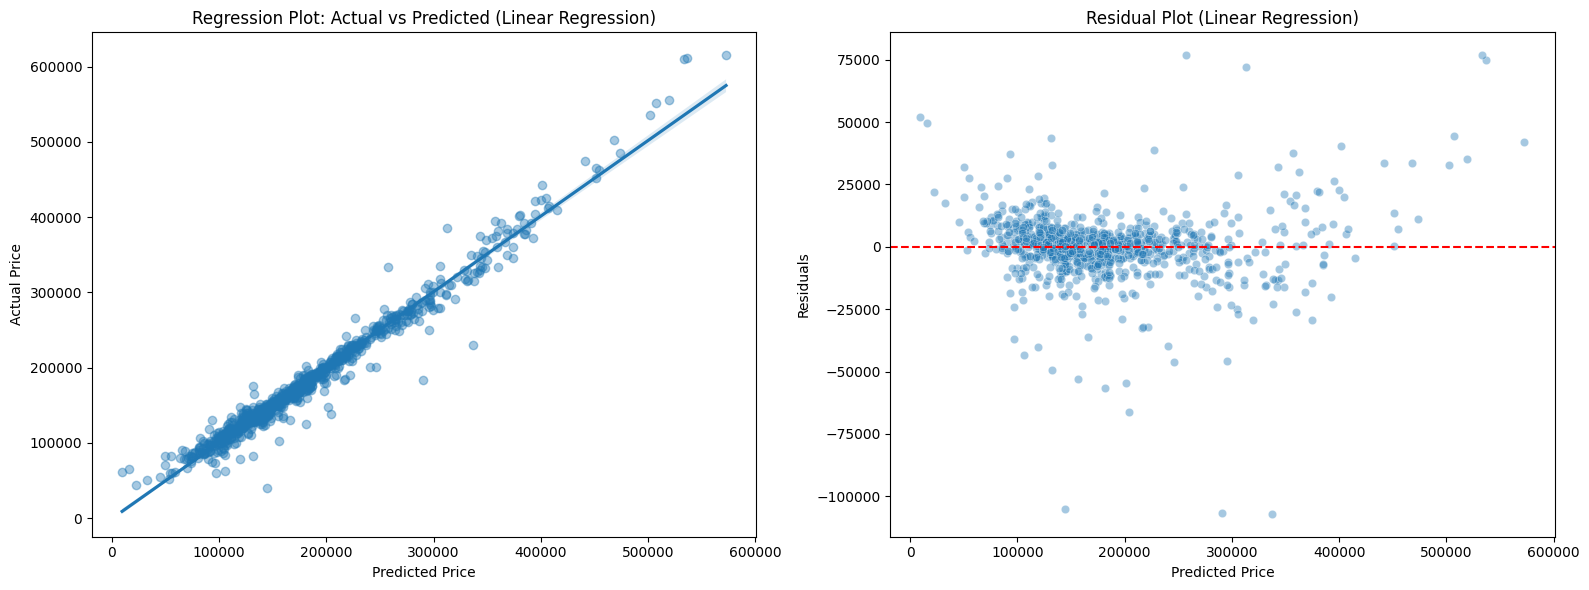

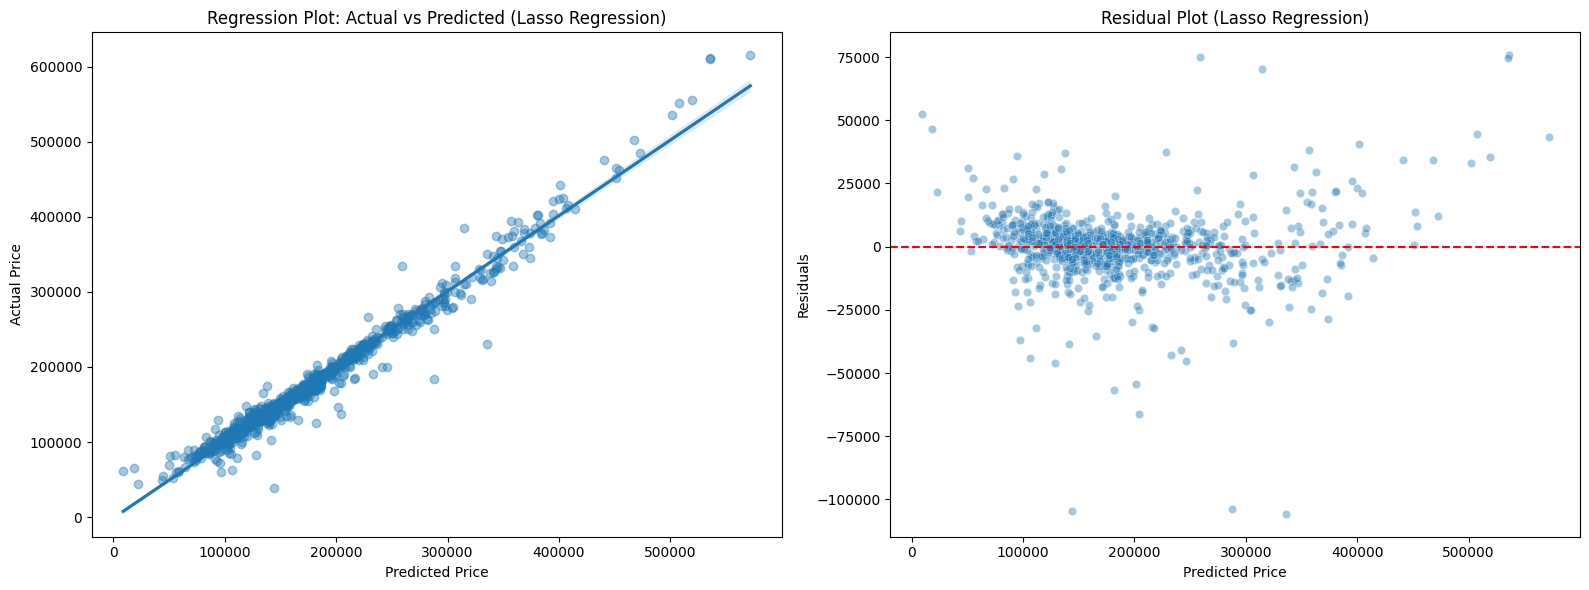

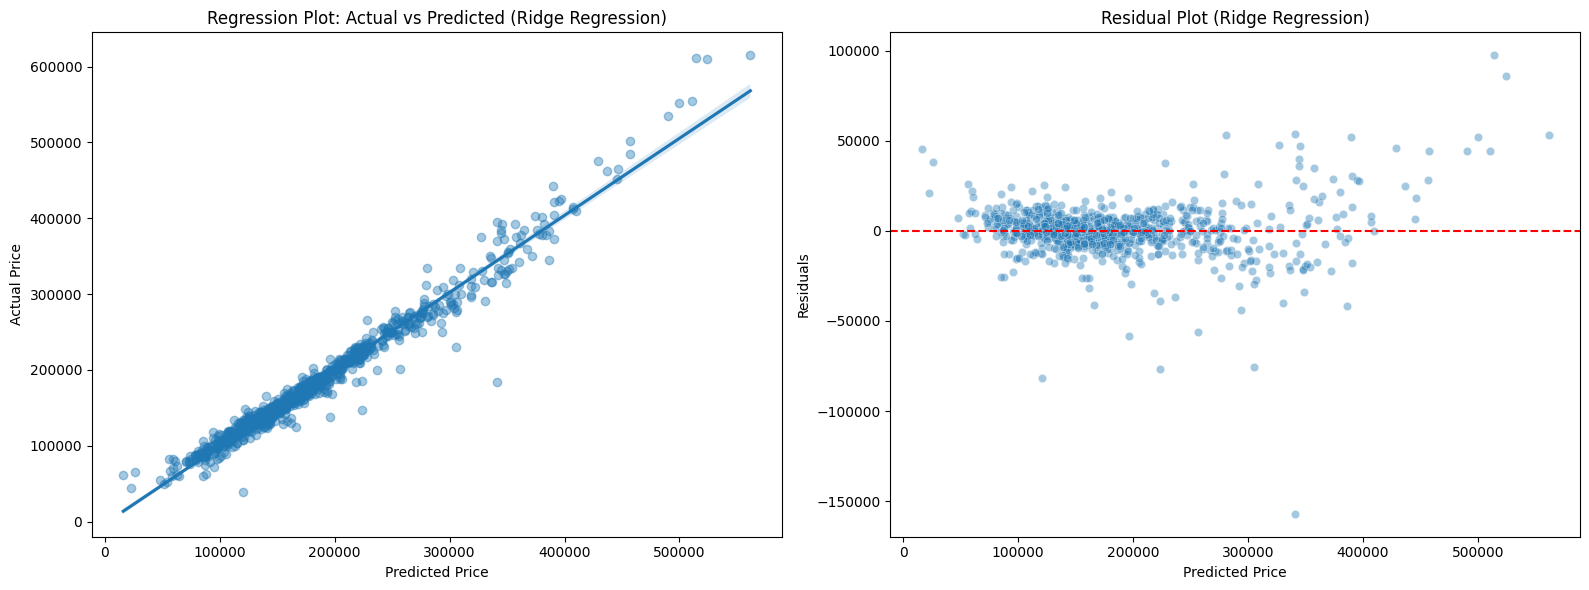

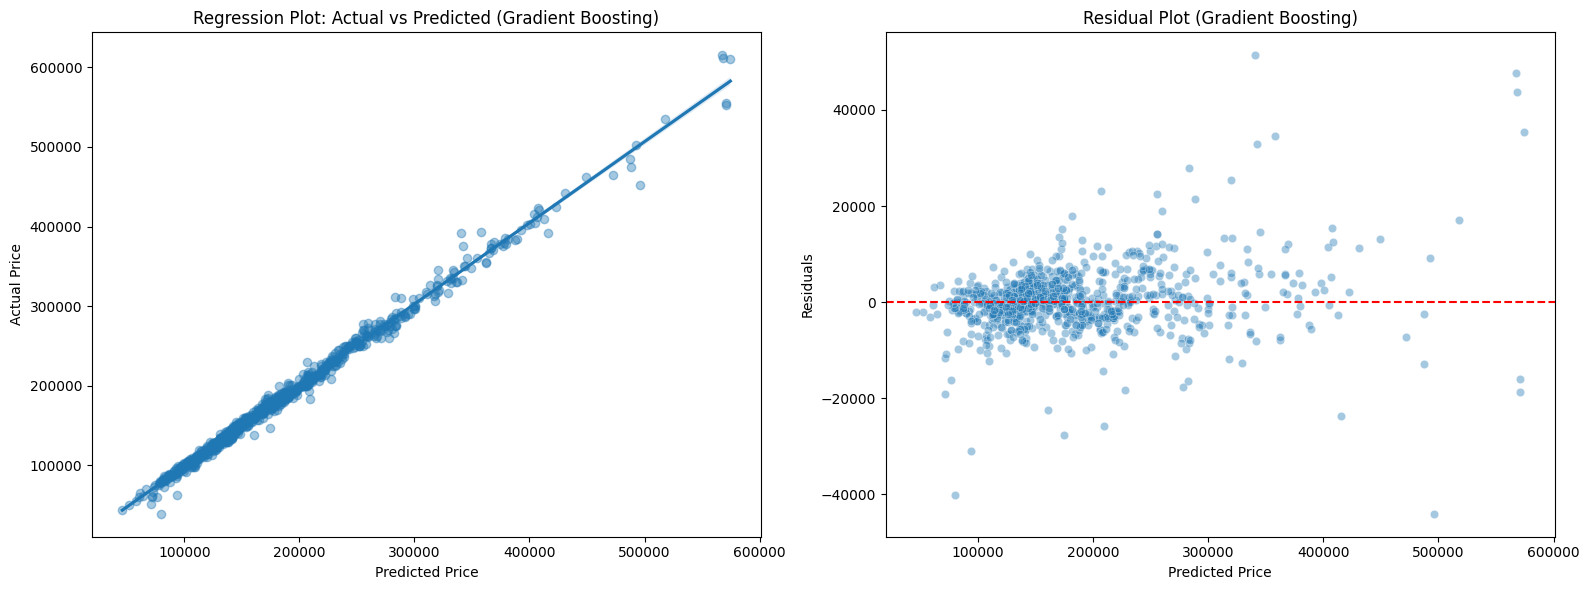

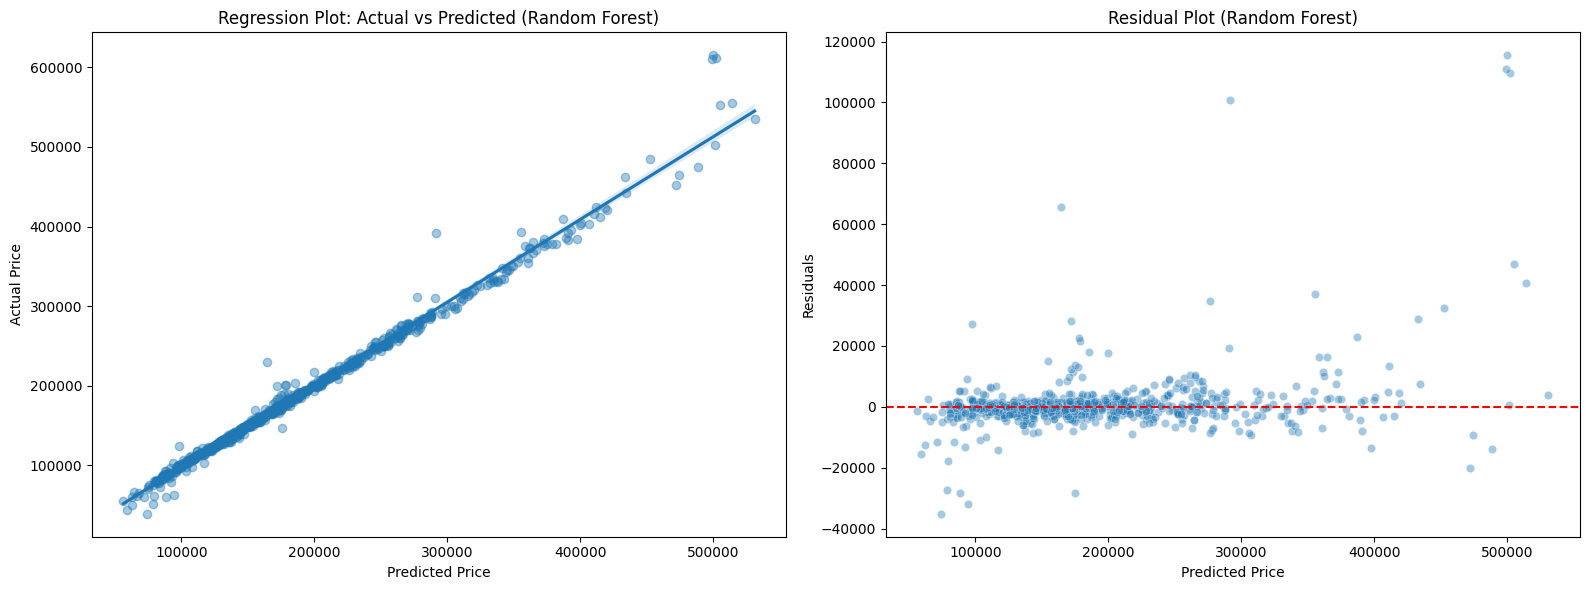

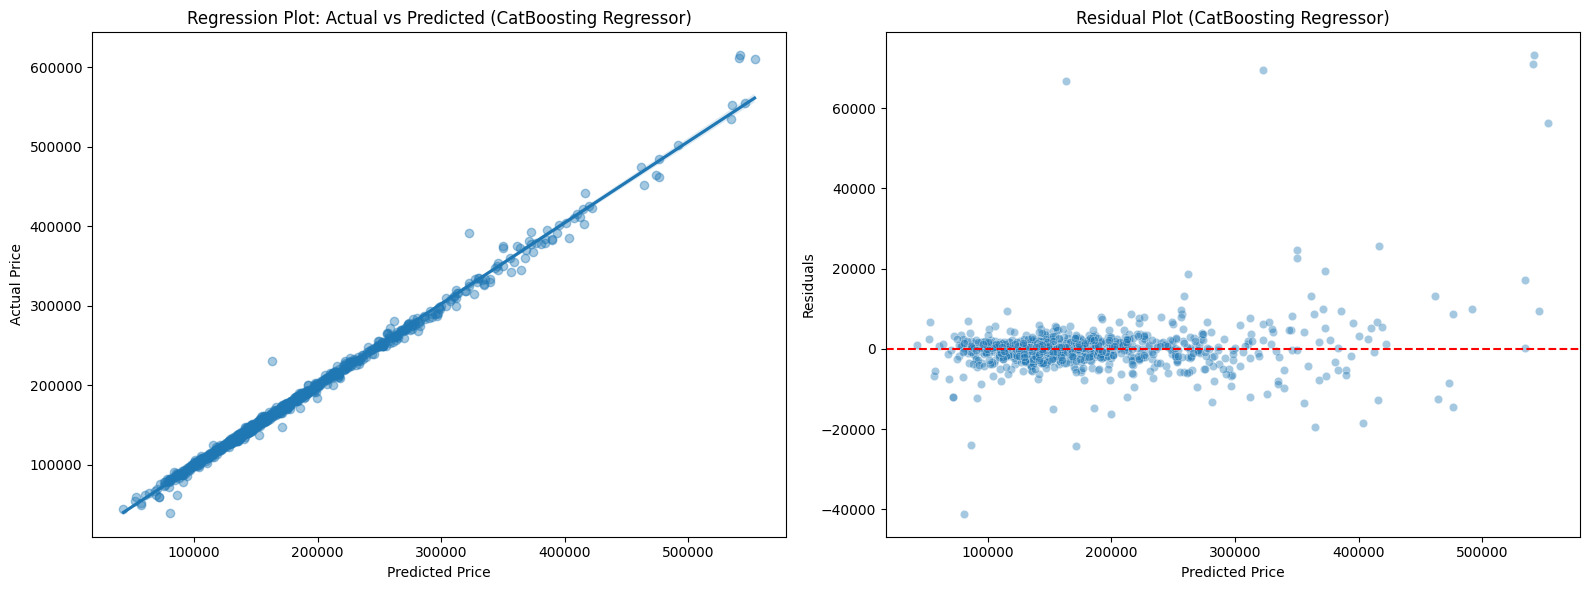

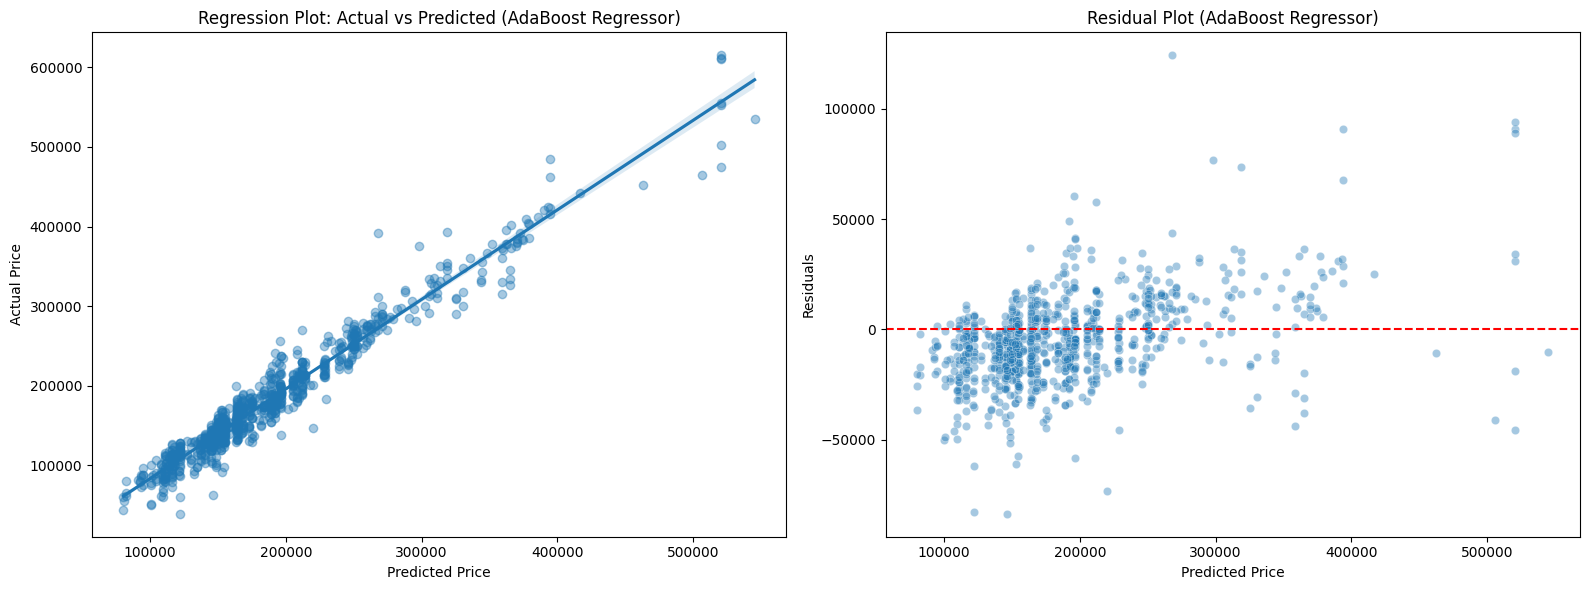

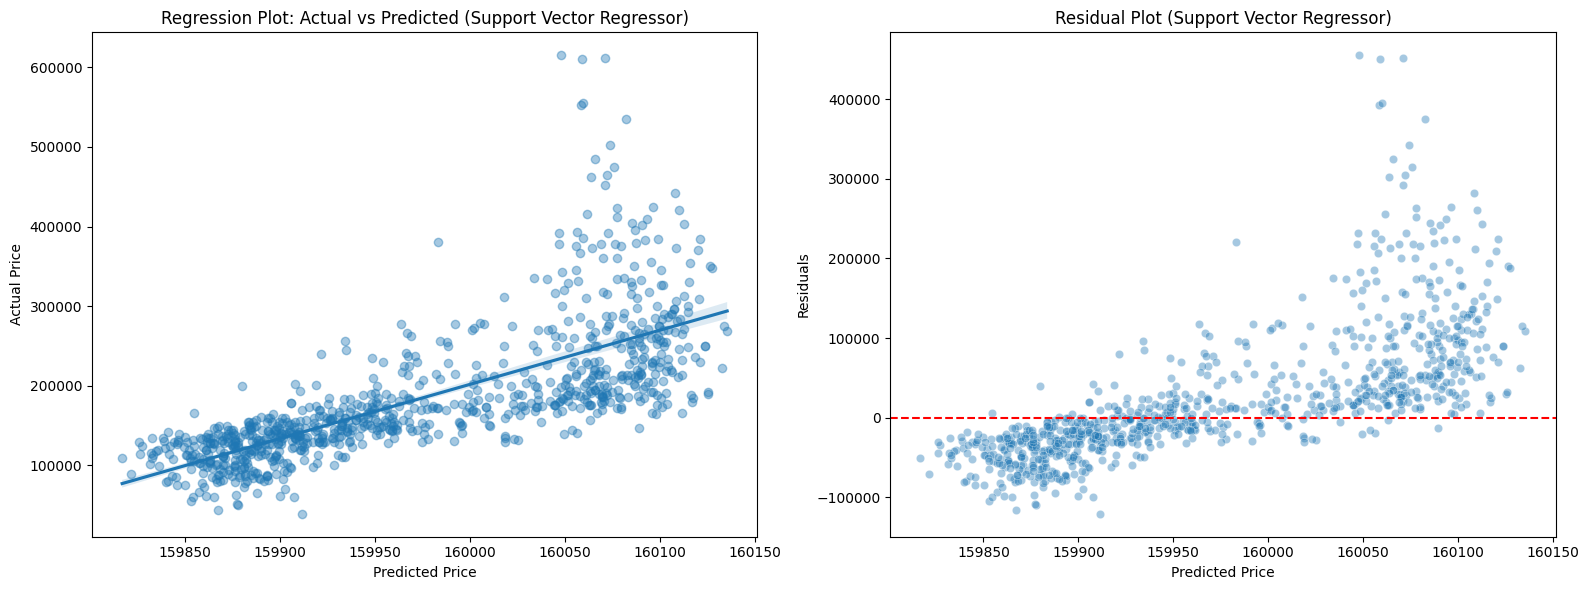

In [253]:
print('\nModel Performance Visualization')
for model_name, regressor in models.items():
    # Ensure the model is trained before predicting
    # The evaluate_regressor_models function already trains the models
    # So, we can directly predict using the models in the 'models' dictionary.
    y_pred = regressor.predict(X_test)

    plt.figure(figsize=(16, 6))

    # Regression Plot
    plt.subplot(1, 2, 1)
    sns.regplot(x=y_pred, y=y_test, scatter_kws={'alpha':0.4})
    plt.xlabel('Predicted Price')
    plt.ylabel('Actual Price')
    plt.title(f'Regression Plot: Actual vs Predicted ({model_name})')

    # Residual Plot
    plt.subplot(1, 2, 2)
    residuals = y_test - y_pred
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.4)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted Price')
    plt.ylabel('Residuals')
    plt.title(f'Residual Plot ({model_name})')

    plt.tight_layout()
    plt.show()

**Cross Validation**

In [254]:
from sklearn.model_selection import cross_validate

print("Cross-Validation Results:")
for model_name, regressor in models.items():
    scoring = {'mae': 'neg_mean_absolute_error', 'mse': 'neg_mean_squared_error', 'r2': 'r2'}
    cv_results = cross_validate(regressor, X, y, cv=5, scoring=scoring)
    print(f"\n{model_name}:")
    print(f"  Average MAE: {-cv_results['test_mae'].mean():.4f}")
    print(f"  Average MSE: {-cv_results['test_mse'].mean():.4f}")
    print(f"  Average RMSE: {np.sqrt(-cv_results['test_mse'].mean()):.4f}")
    print(f"  Average R2: {cv_results['test_r2'].mean():.4f}")

Cross-Validation Results:

Linear Regression:
  Average MAE: 8090.2245
  Average MSE: 207668921.4354
  Average RMSE: 14410.7224
  Average R2: 0.9675

Lasso Regression:
  Average MAE: 7930.5618
  Average MSE: 200179431.7218
  Average RMSE: 14148.4781
  Average R2: 0.9687

Ridge Regression:
  Average MAE: 8217.0766
  Average MSE: 220138868.5745
  Average RMSE: 14837.0775
  Average R2: 0.9657

Gradient Boosting:
  Average MAE: 4379.9539
  Average MSE: 53251252.0687
  Average RMSE: 7297.3455
  Average R2: 0.9917

Random Forest:
  Average MAE: 3331.0697
  Average MSE: 75509555.5577
  Average RMSE: 8689.6234
  Average R2: 0.9882

CatBoosting Regressor:
  Average MAE: 2939.0477
  Average MSE: 48351708.1149
  Average RMSE: 6953.5393
  Average R2: 0.9926

AdaBoost Regressor:
  Average MAE: 16018.3804
  Average MSE: 449792662.9473
  Average RMSE: 21208.3159
  Average R2: 0.9280

Support Vector Regressor:
  Average MAE: 56125.3900
  Average MSE: 6800735019.4412
  Average RMSE: 82466.5691
  Averag

**Hyperparameter Tuning**

In [255]:
# default parameters
print("Default Parameters:")
for model_name, regressor in models.items():
    print(f'{model_name}')
    print(f'parameters: {regressor.get_params()}', end='\n\n')

Default Parameters:
Linear Regression
parameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

Lasso Regression
parameters: {'alpha': 1.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': 1000, 'positive': False, 'precompute': False, 'random_state': None, 'selection': 'cyclic', 'tol': 0.0001, 'warm_start': False}

Ridge Regression
parameters: {'alpha': 1.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}

Gradient Boosting
parameters: {'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_st

In [256]:
# Define parameter grids for hyperparameter tuning
model_params = [
    ('Linear Regression', LinearRegression(), {
        'fit_intercept': [True, False]
    }),
    ('Lasso Regression', Lasso(), {
        'alpha': [0.1, 1.0, 10.0],
        'fit_intercept': [True, False]
    }),
    ('Ridge Regression', Ridge(), {
        'alpha': [0.1, 1.0, 10.0],
        'fit_intercept': [True, False]
    }),
    ('Random Forest', RandomForestRegressor(random_state=42), {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    }),
    ('GBM', GradientBoostingRegressor(random_state=42), {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0],
        'max_depth': [3, 5, 7]
    })
]

In [257]:
# Best parameters and scores initialization
best_model_name = None
best_model = None
best_score = float('-inf')
best_params = None

print("\nHyperparameter Tuning Results:")
for model_name, regressor, params in model_params:
    regressor_grid = GridSearchCV(regressor, params, cv=5, n_jobs=-1, verbose=1).fit(X, y)

    print(f"\nModel: {model_name}")
    print("Best Parameters:", regressor_grid.best_params_)
    print("Best Score:", regressor_grid.best_score_)
    print("\n")

    if regressor_grid.best_score_ > best_score:
        best_model_name = model_name
        best_model = regressor
        best_score = regressor_grid.best_score_
        best_params = regressor_grid.best_params_

print("\n\nFinal Inference")
print(f"Model: {best_model_name}")
print("Best Parameters:", best_params)
print("Best Score:", best_score)



Hyperparameter Tuning Results:
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Model: Linear Regression
Best Parameters: {'fit_intercept': True}
Best Score: 0.9674648436811978


Fitting 5 folds for each of 6 candidates, totalling 30 fits

Model: Lasso Regression
Best Parameters: {'alpha': 10.0, 'fit_intercept': True}
Best Score: 0.9710632855046007


Fitting 5 folds for each of 6 candidates, totalling 30 fits

Model: Ridge Regression
Best Parameters: {'alpha': 0.1, 'fit_intercept': True}
Best Score: 0.9683063211618237


Fitting 5 folds for each of 27 candidates, totalling 135 fits

Model: Random Forest
Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.9884828586594796


Fitting 5 folds for each of 54 candidates, totalling 270 fits


KeyboardInterrupt: 

In [ ]:
best_model

In [ ]:
# Function to find best model parameters
def best_params(model_params, best_model):
    for model_name, regressor, params in model_params.items():
        if best_model == regressor:
            return params
    return None

In [ ]:
# Apply the function
best_model_params = best_params(model_params, best_model)

In [ ]:
best_model_params

In [ ]:
# Final GridSearchCV with best model and its parameter grid
regressor_best_grid = GridSearchCV(best_model, best_model_params, cv=5, n_jobs=-1, verbose=1).fit(X, y)

In [ ]:
regressor_best_grid

In [ ]:
final_model = GradientBoostingRegressor(**regressor_best_grid.best_params_).fit(X, y)

**Cross Validation**

In [ ]:
print("Best Model Cross-Validation")
scoring = {'mae': 'neg_mean_absolute_error', 'mse': 'neg_mean_squared_error', 'r2': 'r2'}
cv_results_final = cross_validate(final_model, X, y, cv=5, scoring=scoring)
print(f"\n{model_name}:")
print(f"  Average MAE: {-cv_results['test_mae'].mean():.4f}")
print(f"  Average MSE: {-cv_results['test_mse'].mean():.4f}")
print(f"  Average RMSE: {np.sqrt(-cv_results['test_mse'].mean()):.4f}")
print(f"  Average R2: {cv_results['test_r2'].mean():.4f}", end="\n\n")

**Feature Importance**

In [ ]:
# creating function to visualize:

def visualize_importance(model, features, start=0, num=len(X), save=False):
    feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': features.columns})
    sorted_feature_imp = feature_imp.sort_values("Value", ascending=False)[start:num]
    display(sorted_feature_imp)
    #print(feature_imp.sort_values("Value",ascending=False)[start:num])
    plt.figure(figsize=(12, 12))
    sns.set(font_scale=0.7)
    palette = sns.color_palette("coolwarm", n_colors=num-start)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value",ascending=False)[start:num], palette=palette)
    plt.title('Visualization of Important Features')
    plt.tight_layout()
    plt.show()

In [ ]:
visualize_importance(final_model, X,start=0, num=45)

In [ ]:
predictions = final_model.predict(test_df.drop(['Id'], axis=1))

In [ ]:
predictions

In [ ]:
test_sample = test_df.drop(['Id'], axis=1).iloc[0].values.reshape(1, -1)
prediction = final_model.predict(test_sample)
print(prediction)

In [ ]:
predict_df = test_df.copy()
predict_df = predict_df.drop(['Id'], axis=1)

## Saving model with Pickle

In [ ]:
import pickle

with open('arko_ml_model.pkl', 'wb') as file:
    pickle.dump(final_model, file)

print("Model saved to arko_ml_model.pkl")

**Loading model and predicting using it**

In [ ]:
# Load model from pickle file
with open('arko_ml_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

result = loaded_model.score(X_test, y_test)
print(result)

print('Predicted SalePrice is : ', loaded_model.predict(predict_df))